In [1]:
import pandas as pd
df=pd.read_csv("data/bestsellers_with_categories.csv")
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [15]:
df.shape


(550, 7)

In [16]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         550 non-null    object 
 1   Author       550 non-null    object 
 2   User_Rating  550 non-null    float64
 3   Reviews      550 non-null    int64  
 4   Price        550 non-null    int64  
 5   Year         550 non-null    int64  
 6   Genre        550 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 30.2+ KB


In [17]:
df.describe()

,User_Rating,Reviews,Price,Year
count,550.000000,550.000000,550.000000,550.000000
mean,4.618364,11953.281818,13.100000,2014.000000
std,0.226980,11731.132017,10.842262,3.165156
min,3.300000,37.000000,0.000000,2009.000000
25%,4.500000,4058.000000,7.000000,2011.000000
50%,4.700000,8580.000000,11.000000,2014.000000
75%,4.800000,17253.250000,16.000000,2017.000000
max,4.900000,87841.000000,105.000000,2019.000000


In [6]:
df.isnull().sum()

Name           0
Author         0
User Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64

In [8]:
df.columns=df.columns.str.replace(" ","_")
df.columns

Index(['Name', 'Author', 'User_Rating', 'Reviews', 'Price', 'Year', 'Genre'], dtype='object')

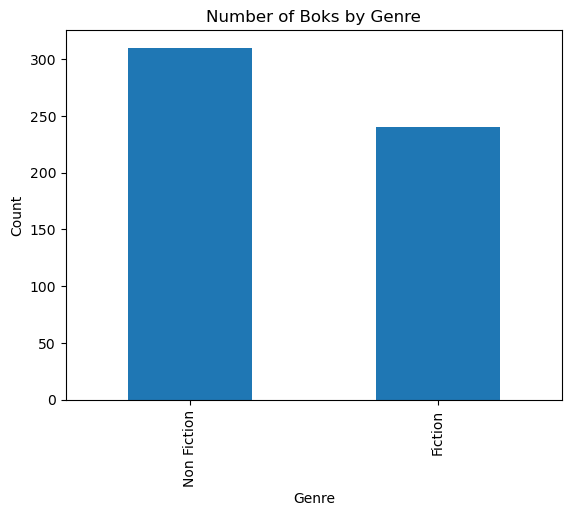

In [18]:
import matplotlib.pyplot as plt

df["Genre"].value_counts().plot(kind="bar")
plt.title("Number of Boks by Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

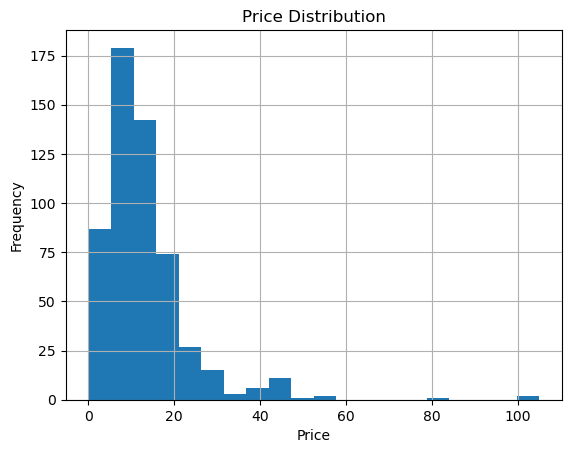

In [19]:
df["Price"].hist(bins=20)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show

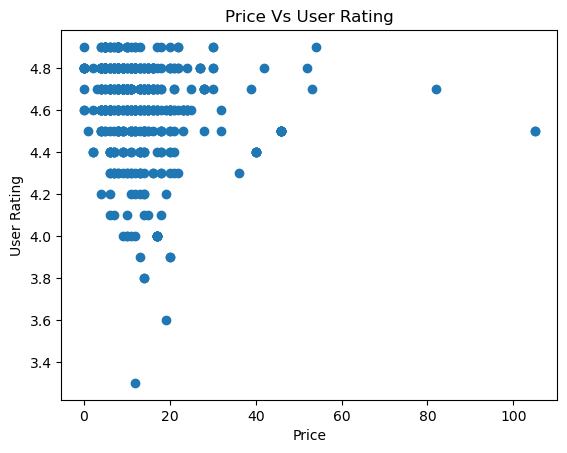

In [20]:
plt.scatter(df["Price"], df["User_Rating"])
plt.xlabel("Price")
plt.ylabel("User Rating")
plt.title("Price Vs User Rating")
plt.show()

In [13]:
df.corr(numeric_only=True)

,User_Rating,Reviews,Price,Year
User_Rating,1.000000,-0.001729,-0.133086,0.242383
Reviews,-0.001729,1.000000,-0.109182,0.263560
Price,-0.133086,-0.109182,1.000000,-0.153979
Year,0.242383,0.263560,-0.153979,1.000000


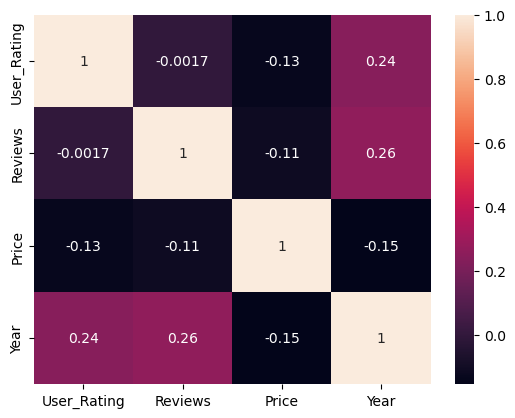

In [23]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

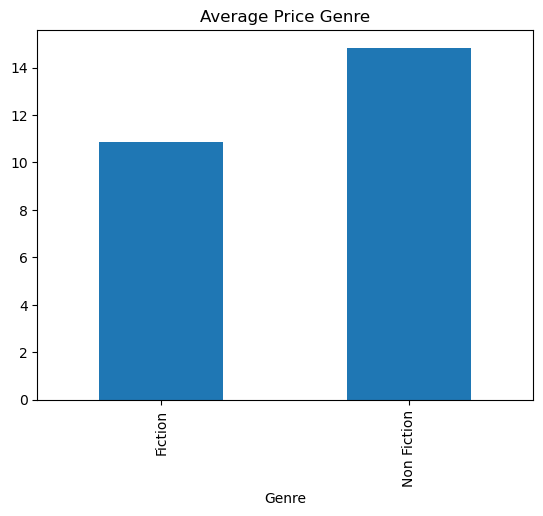

In [22]:
df.groupby("Genre")["Price"].mean().plot(kind="bar")
plt.title("Average Price Genre")
plt.show()

In [25]:
X=df[["Price","User_Rating","Reviews"]]

In [26]:
from sklearn.cluster import KMeans

In [27]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)

c:\Users\ntj\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\ntj\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\ntj\AppData\Local\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ntj\AppData\Local\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, clos

In [28]:
df["Cluster"].value_counts()

Cluster
0    396
1    138
2     16
Name: count, dtype: int64

In [29]:
df.head()

,Name,Author,User_Rating,Reviews,Price,Year,Genre,Cluster
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction,1
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction,0
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction,1
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction,1
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction,0


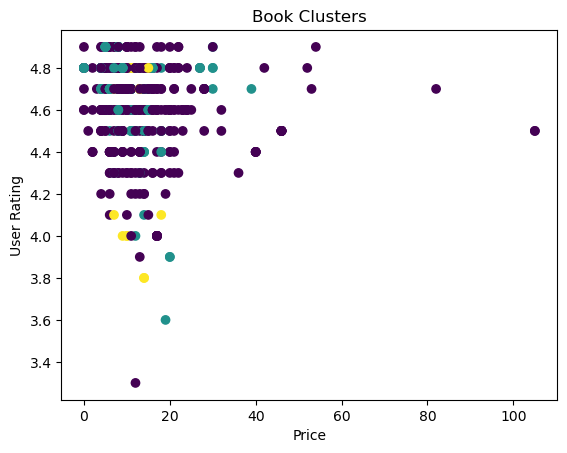

In [30]:
import matplotlib.pyplot as plt

plt.scatter(df["Price"], df["User_Rating"], c=df["Cluster"])
plt.xlabel("Price")
plt.ylabel("User Rating")
plt.title("Book Clusters")
plt.show()


In [32]:
df.groupby("Cluster")[["Price","User_Rating","Reviews"]].mean()

,Price,User_Rating,Reviews
Cluster,,,
0,14.020202,4.604798,6235.063131
1,10.623188,4.681159,22966.478261
2,11.687500,4.412500,58490.375000
